In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [3]:
data = fetch_ucirepo(id=183)

X = data.data.features
y = data.data.targets

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1994, 127)
y shape: (1994, 1)


In [4]:
X.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,?,0.02,0.12,0.45,?,?,?,?,0.00,?
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,?,0.01,0.21,0.02,?,?,?,?,0.00,?
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,?,0.02,0.39,0.28,?,?,?,?,0.00,?
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,?,0.04,0.09,0.02,?,?,?,?,0.00,?


In [5]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 127 entries, state to PolicBudgPerPop
dtypes: float64(99), int64(2), str(26)
memory usage: 1.9 MB


In [6]:
y.head()

,ViolentCrimesPerPop
0,0.20
1,0.67
2,0.43
3,0.12
4,0.03


In [8]:
X.select_dtypes(include="object").columns

C:\Users\DELL\AppData\Local\Temp\ipykernel_9128\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['county', 'community', 'communityname', 'OtherPerCap', 'LemasSwornFT',
       'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop',
       'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop',
       'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp',
       'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits',
       'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'PolicCars', 'PolicOperBudg',
       'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'PolicBudgPerPop'],
      dtype='str')

In [9]:
# Replace '?' with missing values
X = X.replace("?", np.nan)

# Remove non-predictive columns
drop_cols = ["state", "county", "community", "communityname", "fold"]
X = X.drop(columns=drop_cols, errors="ignore")

# Convert everything to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Convert target to numeric
y = y.apply(pd.to_numeric, errors="coerce").squeeze()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Median imputation, fitted ONLY on training data
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Missing values in train:", X_train.isna().sum().sum())
print("Missing values in test:", X_test.isna().sum().sum())

Training set: (1595, 122)
Testing set: (399, 122)
Missing values in train: 0
Missing values in test: 0


In [ ]:
from sklearn.preprocessing import StandardScaler

# Feature engineering
X_train["SocioEconomicStress"] = X_train[
    ["PctUnemployed", "PctPopUnderPov", "PctNotHSGrad"]
].mean(axis=1)

X_test["SocioEconomicStress"] = X_test[
    ["PctUnemployed", "PctPopUnderPov", "PctNotHSGrad"]
].mean(axis=1)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scale training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (1595, 123)
Scaled testing data: (399, 123)


In [12]:
print("Dataset shape:", X.shape)

print("\nData types:")
print(X.dtypes.value_counts())

print("\nMissing values:")
print(X.isna().sum().sort_values(ascending=False).head(15))

print("\nTarget statistics:")
print(y.describe())

Dataset shape: (1994, 122)

Data types:
float64    122
Name: count, dtype: int64

Missing values:
LemasSwFTFieldPerPop    1675
LemasSwFTFieldOps       1675
RacialMatchCommPol      1675
PctPolicWhite           1675
LemasSwornFT            1675
LemasSwFTPerPop         1675
LemasTotReqPerPop       1675
LemasTotalReq           1675
PolicPerPop             1675
PolicReqPerOffic        1675
PolicBudgPerPop         1675
PolicCars               1675
LemasGangUnitDeploy     1675
LemasPctPolicOnPatr     1675
PolicAveOTWorked        1675
dtype: int64

Target statistics:
count    1994.000000
mean        0.237979
std         0.232985
min         0.000000
25%         0.070000
50%         0.150000
75%         0.330000
max         1.000000
Name: ViolentCrimesPerPop, dtype: float64


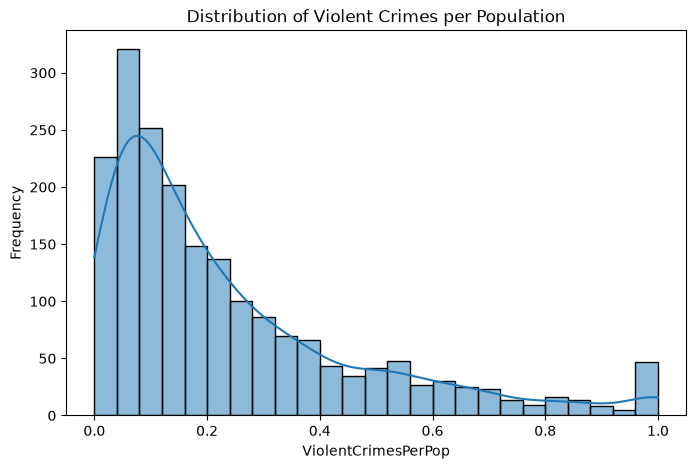

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=True)
plt.title("Distribution of Violent Crimes per Population")
plt.xlabel("ViolentCrimesPerPop")
plt.ylabel("Frequency")
plt.show()

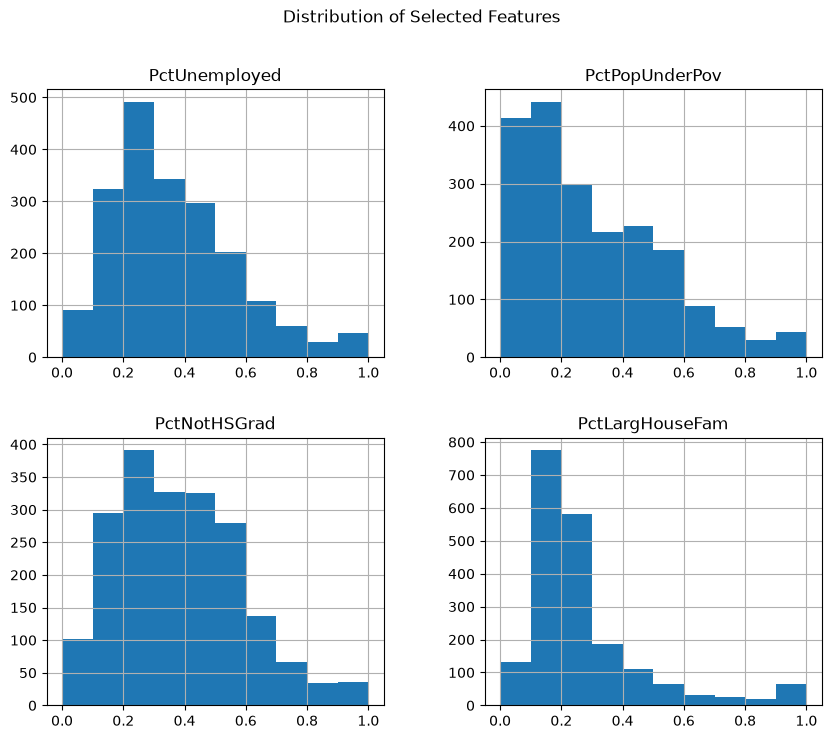

In [14]:
features_to_plot = [
    "PctUnemployed",
    "PctPopUnderPov",
    "PctNotHSGrad",
    "PctLargHouseFam"
]

X[features_to_plot].hist(figsize=(10, 8))
plt.suptitle("Distribution of Selected Features")
plt.show()

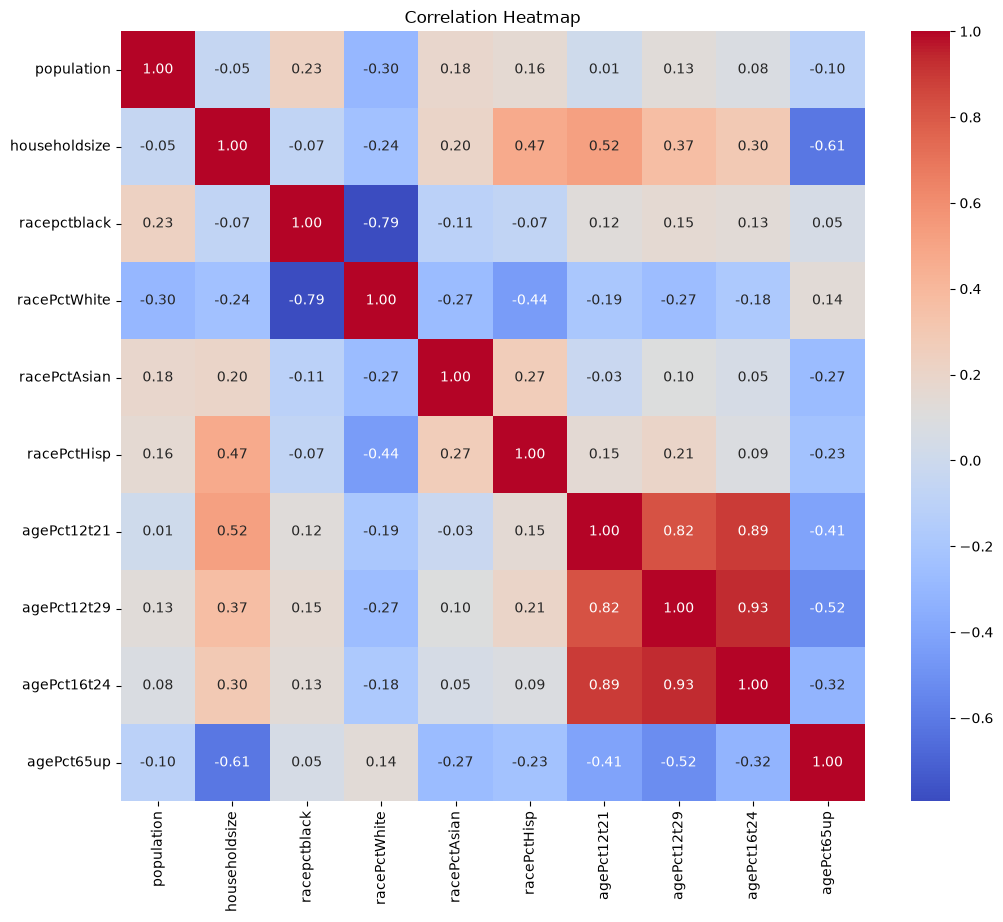

In [15]:
corr_data = pd.concat([X, y], axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_data.corr(numeric_only=True).iloc[:10, :10],
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

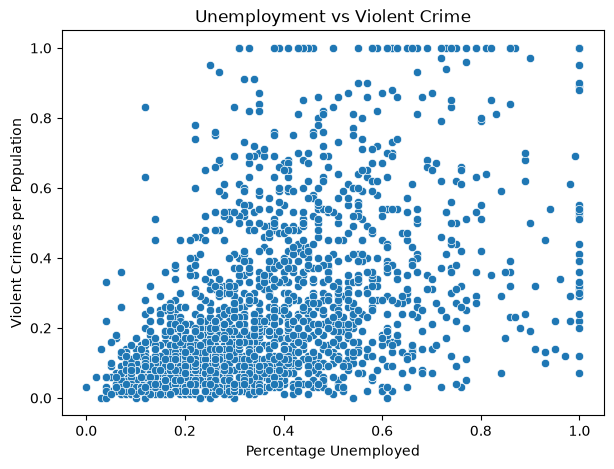

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X["PctUnemployed"], y=y)
plt.title("Unemployment vs Violent Crime")
plt.xlabel("Percentage Unemployed")
plt.ylabel("Violent Crimes per Population")
plt.show()

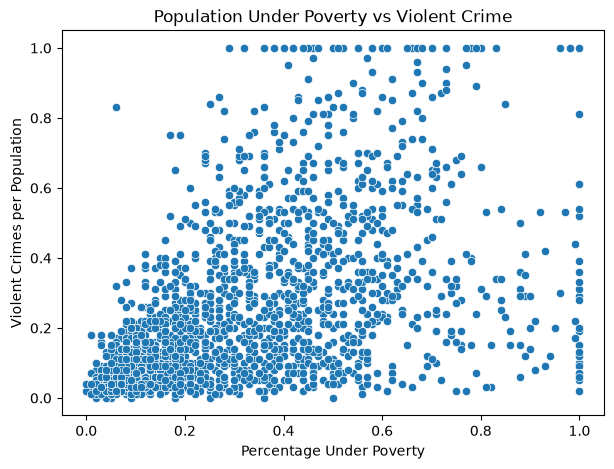

In [17]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X["PctPopUnderPov"], y=y)
plt.title("Population Under Poverty vs Violent Crime")
plt.xlabel("Percentage Under Poverty")
plt.ylabel("Violent Crimes per Population")
plt.show()

In [18]:
print("Duplicate rows:", X.duplicated().sum())

Duplicate rows: 0


In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

models = {
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    ),

    "SVR": SVR(
        C=10,
        kernel="rbf"
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}

results = []
trained_models = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    trained_models[name] = model

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2", ascending=False)

results_df

,Model,R2,RMSE,MAE
1,Random Forest,0.616139,0.135593,0.092560
2,Gradient Boosting,0.603474,0.137811,0.092742
4,KNN,0.562535,0.144750,0.097549
3,SVR,0.514760,0.152450,0.109468
0,Decision Tree,0.279527,0.185762,0.116272


In [20]:
#hyperparameter turning
from sklearn.model_selection import GridSearchCV

# Random Forest tuning
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print("Random Forest")
print("Best parameters:", rf_grid.best_params_)
print("Best CV R2:", rf_grid.best_score_)


# Gradient Boosting tuning
gb = GradientBoostingRegressor(random_state=42)

gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    gb,
    gb_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train_scaled, y_train)

print("\nGradient Boosting")
print("Best parameters:", gb_grid.best_params_)
print("Best CV R2:", gb_grid.best_score_)

Random Forest
Best parameters: {'max_depth': None, 'n_estimators': 200}
Best CV R2: 0.6448539920222182

Gradient Boosting
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV R2: 0.653794620756363


In [21]:
from sklearn.model_selection import cross_val_score

# Use the tuned models
best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_

# 5-fold cross-validation
rf_cv = cross_val_score(
    best_rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

gb_cv = cross_val_score(
    best_gb,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Random Forest 5-Fold CV R2:")
print(rf_cv)
print("Mean:", rf_cv.mean())

print("\nGradient Boosting 5-Fold CV R2:")
print(gb_cv)
print("Mean:", gb_cv.mean())

Random Forest 5-Fold CV R2:
[0.64823654 0.67198917 0.64135136 0.65487421 0.6146935 ]
Mean: 0.6462289578699112

Gradient Boosting 5-Fold CV R2:
[0.67184359 0.66883874 0.65181884 0.65771946 0.61644487]
Mean: 0.6533330987294148


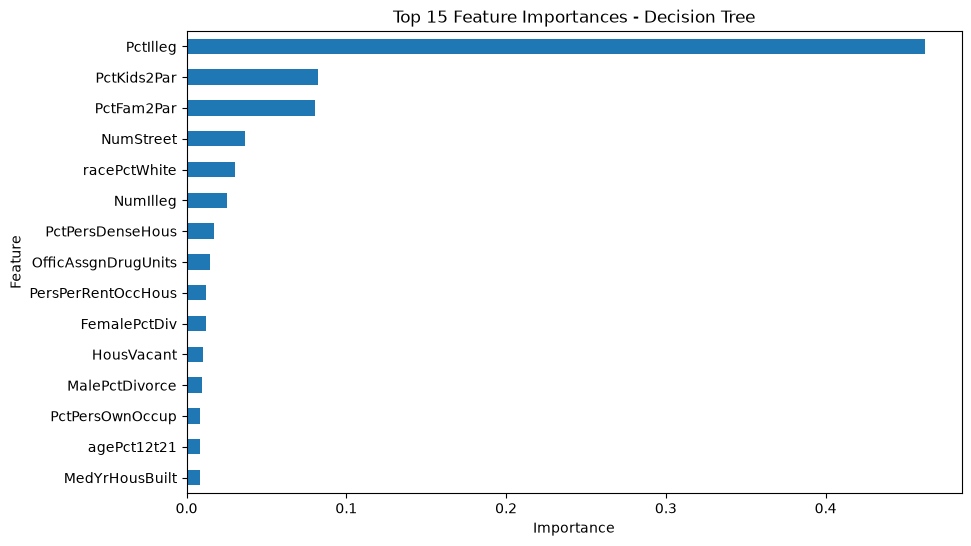

In [23]:
# Feature Importance from Decision Tree

dt_model = trained_models["Decision Tree"]

importance = pd.Series(
    dt_model.feature_importances_,
    index=X_train.columns
)

top_features = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

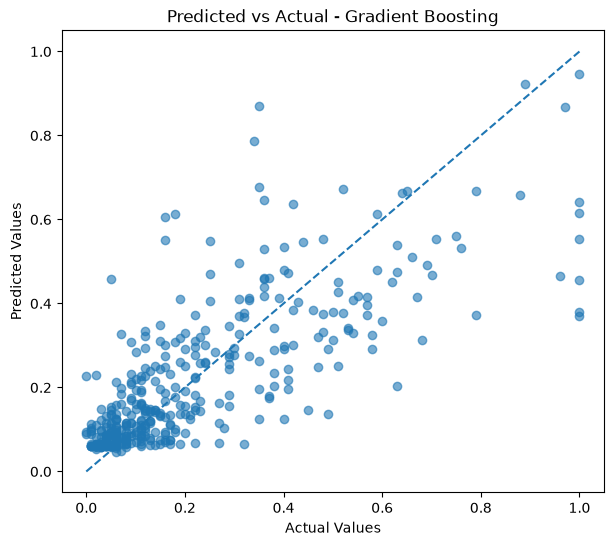

In [24]:
# Predicted vs Actual - Gradient Boosting

best_model = gb_grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Predicted vs Actual - Gradient Boosting")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

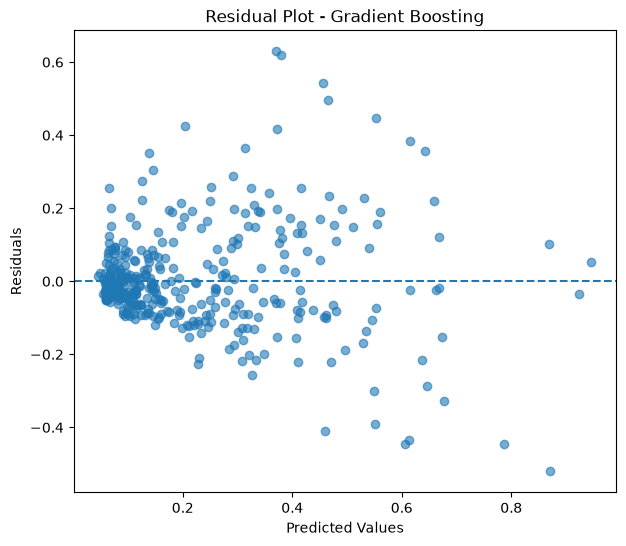

In [25]:
# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot - Gradient Boosting")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

In [26]:
# Final Regression Results

final_results = results_df.copy()

final_results

,Model,R2,RMSE,MAE
1,Random Forest,0.616139,0.135593,0.092560
2,Gradient Boosting,0.603474,0.137811,0.092742
4,KNN,0.562535,0.144750,0.097549
3,SVR,0.514760,0.152450,0.109468
0,Decision Tree,0.279527,0.185762,0.116272


In [27]:
# Evaluate tuned models on the test set

tuned_results = []

for name, model in [
    ("Tuned Random Forest", rf_grid.best_estimator_),
    ("Tuned Gradient Boosting", gb_grid.best_estimator_)
]:
    pred = model.predict(X_test_scaled)

    tuned_results.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred)
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.615273,0.135745,0.092949
1,Tuned Gradient Boosting,0.603474,0.137811,0.092742
